In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [3]:
# Reading the data
data = pd.read_csv("creditcard.csv")

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Feature Engineering

## Computing time based features

In [4]:
# Converting the 'Time' (which is in seconds) to more readable features

# Converting into hours
data['Time_Hours'] = data['Time'] / 3600  

# Converting into days
data['Time_Days'] = data['Time'] / 86400  # Convert to days

# Computing time difference from previous transaction
data['Time_Since_Last_Transaction'] = data['Time'].diff().fillna(0)

# Identify peak and night transactions
# Assumptions:
# Peak hours are from 8AM to 8PM
# Night transaction hours are from 11PM to 5AM
data['Is_Peak_Hour'] = data['Time_Hours'].apply(lambda x: 1 if 8 <= x % 24 <= 20 else 0)
data['Is_Night_Transaction'] = data['Time_Hours'].apply(lambda x: 1 if (x % 24 >= 23 or x % 24 <= 5) else 0)

print(data[['Time', 'Time_Since_Last_Transaction', 'Is_Peak_Hour', 'Is_Night_Transaction']].head())


   Time  Time_Since_Last_Transaction  Is_Peak_Hour  Is_Night_Transaction
0   0.0                          0.0             0                     1
1   0.0                          0.0             0                     1
2   1.0                          1.0             0                     1
3   1.0                          0.0             0                     1
4   2.0                          1.0             0                     1


In [5]:
data.isna().sum()

Time                           0
V1                             0
V2                             0
V3                             0
V4                             0
V5                             0
V6                             0
V7                             0
V8                             0
V9                             0
V10                            0
V11                            0
V12                            0
V13                            0
V14                            0
V15                            0
V16                            0
V17                            0
V18                            0
V19                            0
V20                            0
V21                            0
V22                            0
V23                            0
V24                            0
V25                            0
V26                            0
V27                            0
V28                            0
Amount                         0
Class     

+ We see that the dataset doesn't contain any Null Values

In [6]:
import numpy as np
# Tracking the number of transactions has occured in last one hour and 24 hours rolling window
data['Transactions_Last_1hr'] = data.rolling(window=10)['Time'].apply(lambda x: np.sum(np.diff(x) <= 3600), raw=False).fillna(0)
data['Transactions_Last_24hrs'] = data.rolling(window=50)['Time'].apply(lambda x: np.sum(np.diff(x) <= 86400), raw=False).fillna(0)

print(data[['Time', 'Transactions_Last_1hr', 'Transactions_Last_24hrs']])


            Time  Transactions_Last_1hr  Transactions_Last_24hrs
0            0.0                    0.0                      0.0
1            0.0                    0.0                      0.0
2            1.0                    0.0                      0.0
3            1.0                    0.0                      0.0
4            2.0                    0.0                      0.0
...          ...                    ...                      ...
284802  172786.0                    9.0                     49.0
284803  172787.0                    9.0                     49.0
284804  172788.0                    9.0                     49.0
284805  172788.0                    9.0                     49.0
284806  172792.0                    9.0                     49.0

[284807 rows x 3 columns]


In [7]:
# dropping the original Time feature as we have abstracted all the required features from it
data.drop(columns=['Time'], inplace=True)

In [8]:
# spltting the independant and dependant features
X = data.drop(columns=["Class"])  
Y = data["Class"]  

In [9]:
Y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

+ We see that there are huge class imbalance in the response feature, which makes the model to focus on the class which has more number of transactions associated with. More number of "0" class transaction will decrease the performance of model in detecting the fraud

+ Lets, make the response variable balanced by using SMOTE 

In [10]:
smote = SMOTE(sampling_strategy=0.5, random_state=42)  
X_resampled, Y_resampled = smote.fit_resample(X, Y)

In [11]:
Y_resampled.value_counts()

Class
0    284315
1    142157
Name: count, dtype: int64

+ Now we see that response variable is balanced

In [12]:
# Spliting the data into train and test sets
# 80% training
# 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=42)


## Standardization

+ Helps the model to give equal importance to all the features such that minimal features will not dominate in the prediction

In [13]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Supervised Learning

### Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Training Logistic Regression Model
logistic_reg = LogisticRegression(class_weight="balanced", random_state=42)
logistic_reg.fit(X_train, y_train)

# Predicting the model outputs using test data
y_pred = logistic_reg.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     56777
           1       0.96      0.94      0.95     28518

    accuracy                           0.97     85295
   macro avg       0.97      0.96      0.97     85295
weighted avg       0.97      0.97      0.97     85295

AUC-ROC: 0.9626501610409445


In [17]:
# If X_train is a NumPy array, converting it back to a DataFrame
if isinstance(X_train, np.ndarray):
    # Assuming is the original data frame
    X_train = pd.DataFrame(X_train, columns=X.columns)  


# Extracting the coefficients
feature_names = X_train.columns
coefficients = logistic_reg.coef_[0]
intercept = logistic_reg.intercept_[0]

Summary_data = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
})

# Adding the intercept separately
Intercept_data = pd.DataFrame({"Feature": ["Intercept"], "Coefficient": [intercept]})
Summary_data = pd.concat([Intercept_data, Summary_data], ignore_index=True)

Summary_data


,Feature,Coefficient
0,Intercept,8.913218
1,V1,3.655536
2,V2,1.625042
3,V3,1.273907
4,V4,2.456873
5,V5,2.833322
6,V6,-0.836711
7,V7,-2.342654
8,V8,-2.055721
9,V9,-1.140496


+ Statistically we can say that the features with the positive slope contributes to the high chances of having fraud. 

Lets understood how different features contributes to chances of having fraud:

1. Amount : High amount transactions indicates fraud transactions.
2. Transactions_Last_1hr and Transactions_Last_24hrs : This indicates that transactions done right after i.e after around 24 hrs the credit card was stolen indicates fraud transactions beacuse the victim tries to take money with in short period of time the card was stolen.
3. Time_Since_Last_Transaction : This indicates that as the time between the transaction increases there are high chances of indicating fraud transaction because victim usually wait for some time before doing transaction after one transaction is successfull.
4. Also there are some features which are contributing to chances of having fraud.


## Supervised Learning

### XGBoost Classifier

In [29]:
from xgboost import XGBClassifier

# Training XGBoost Model
xgb = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]), random_state=42)
xgb.fit(X_train, y_train)

# Predicting the model outputs using test data
y_pred = xgb.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56777
           1       1.00      1.00      1.00     28518

    accuracy                           1.00     85295
   macro avg       1.00      1.00      1.00     85295
weighted avg       1.00      1.00      1.00     85295

AUC-ROC: 0.9998503714706952


[0.01504866 0.00965341 0.02175328 0.0616461  0.00442572 0.00516636
 0.00931436 0.02057588 0.00640799 0.02707225 0.00839988 0.02522962
 0.01023986 0.6046572  0.00437386 0.00551483 0.00923126 0.00522225
 0.00720436 0.00451917 0.00724389 0.00570218 0.00492136 0.00367695
 0.00791923 0.00472472 0.00090702 0.003567   0.01348008 0.00562948
 0.         0.04883052 0.00928715 0.01845404 0.         0.        ]


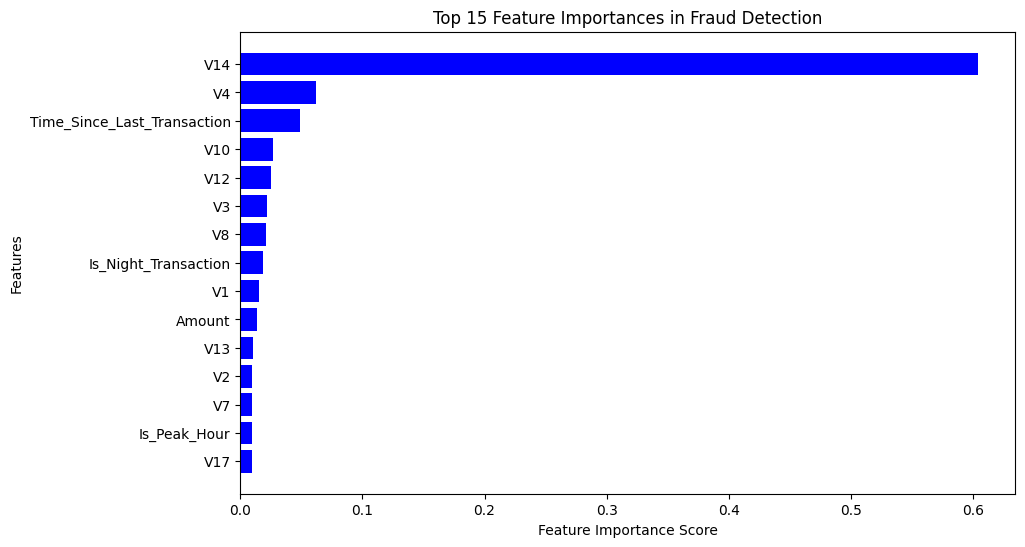

In [30]:
import matplotlib.pyplot as plt
#Getting the feature importances
feature_importances = xgb.feature_importances_
print(feature_importances)
feature_names = X.columns

# Sorting features by importance
sort_indices = np.argsort(feature_importances)[::-1]
sort_features = [feature_names[i] for i in sort_indices]
sort_importances = feature_importances[sort_indices]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(sort_features[:15], sort_importances[:15], color='blue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances in Fraud Detection")
plt.gca().invert_yaxis() 
plt.show()

+ As per the Xgboost model analyis the chances of having fraud transactions are dependant on:

1. Time_Since_Last_Transaction: The time between the multiple transactions after the card was stolen increases.
2. Amount: Transactions done with large amount.
3. Transactions done during night have the high chances of indicating fraud than the transactions done during peak hours.

## UnSupervised Learning

### Isolation Forest

In [18]:
from sklearn.ensemble import IsolationForest

# Training the Isolation Forest
isolation_forest = IsolationForest(contamination=0.01, random_state=42)
isolation_forest.fit(X_train)


# Predicting the model outputs using test data
y_pred = isolation_forest.predict(X_test)

# Isolation Forest model generates the outputs in form of -1's and 1's
# Marking 1 as fraud transactions and 0 as good transactions
y_pred = [1 if x == -1 else 0 for x in y_pred]  

# Evaluation
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      1.00      0.80     56777
           1       0.98      0.03      0.06     28518

    accuracy                           0.68     85295
   macro avg       0.82      0.51      0.43     85295
weighted avg       0.77      0.68      0.55     85295

AUC-ROC: 0.5148670029969975


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


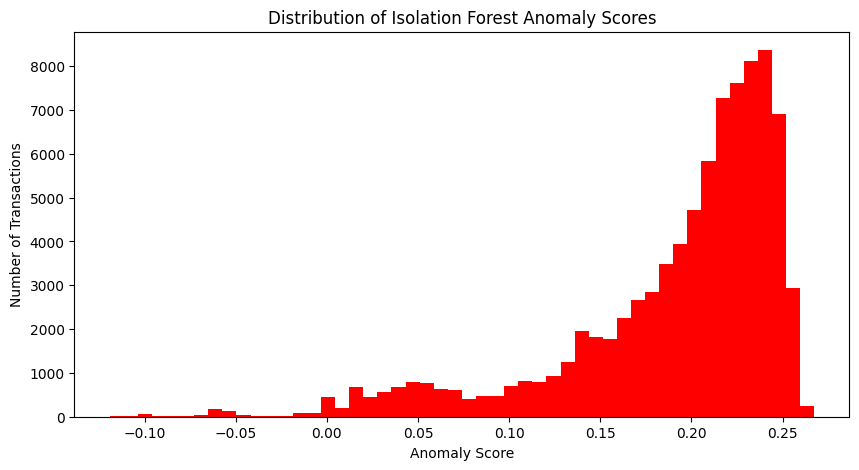

In [24]:
import matplotlib.pyplot as plt

# Ensuring X_test is a DataFrame
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)

df_test = X_test.copy()
df_test['Anomaly_Score'] = isolation_forest.decision_function(X_test)

# Visualizing the anomaly scores
plt.figure(figsize=(10, 5))
plt.hist(df_test['Anomaly_Score'], bins=50, color='red', alpha=1)
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Transactions")
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.show()


+ The Isolation forest indicates that the high anamoly scores has lower risk.
+ We see that most of the transactions are falling between 0.15 to 0.25 has the lower risk of being fraud.
+ Transactions with scores less than 0 are most likely fraudlent.
+ Transactions with scores less than -0.05 can be considered as true fraud. 


## How we can use this in real world?

In [25]:
# Defining a fraud threshold,bottom 5% as the frauds
threshold = np.percentile(df_test["Anomaly_Score"], 5)  

# Flag transactions as fraud if their anomaly score is below the threshold
df_test["Fraud_Flag"] = df_test["Anomaly_Score"] < threshold

# Count flagged fraud transactions
print(df_test["Fraud_Flag"].value_counts())

Fraud_Flag
False    81030
True      4265
Name: count, dtype: int64


+ So we can conclude that there are 4265 fraud transactions

In [26]:
from sklearn.svm import OneClassSVM

# Training the One-Class SVM Model
oneclass_svm = OneClassSVM(nu=0.01, kernel="rbf", gamma="auto")
oneclass_svm.fit(X_train)

# Predicting the model outputs using test data
y_pred = oneclass_svm.predict(X_test)

# One Class model generates the outputs in form of -1's and 1's
# Marking 1 as fraud transactions and 0 as good transactions
y_pred_svm = [1 if x == -1 else 0 for x in y_pred]  

# Evaluation
print(classification_report(y_test, y_pred_svm))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.67      0.99      0.80     56777
           1       0.34      0.01      0.02     28518

    accuracy                           0.66     85295
   macro avg       0.50      0.50      0.41     85295
weighted avg       0.56      0.66      0.54     85295

AUC-ROC: 0.5000558234750915


## Model Comparison

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


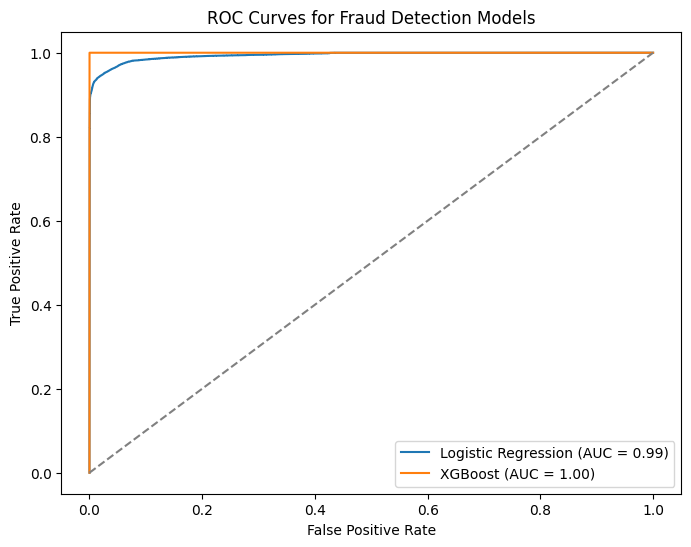

/var/folders/_h/ngxdgxln57gb923874j8w4rh0000gn/T/ipykernel_35801/4211837903.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results["Model"], y=df_results[metric], palette="coolwarm")
/var/folders/_h/ngxdgxln57gb923874j8w4rh0000gn/T/ipykernel_35801/4211837903.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results["Model"], y=df_results[metric], palette="coolwarm")
/var/folders/_h/ngxdgxln57gb923874j8w4rh0000gn/T/ipykernel_35801/4211837903.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_results["Model"], y=df_re

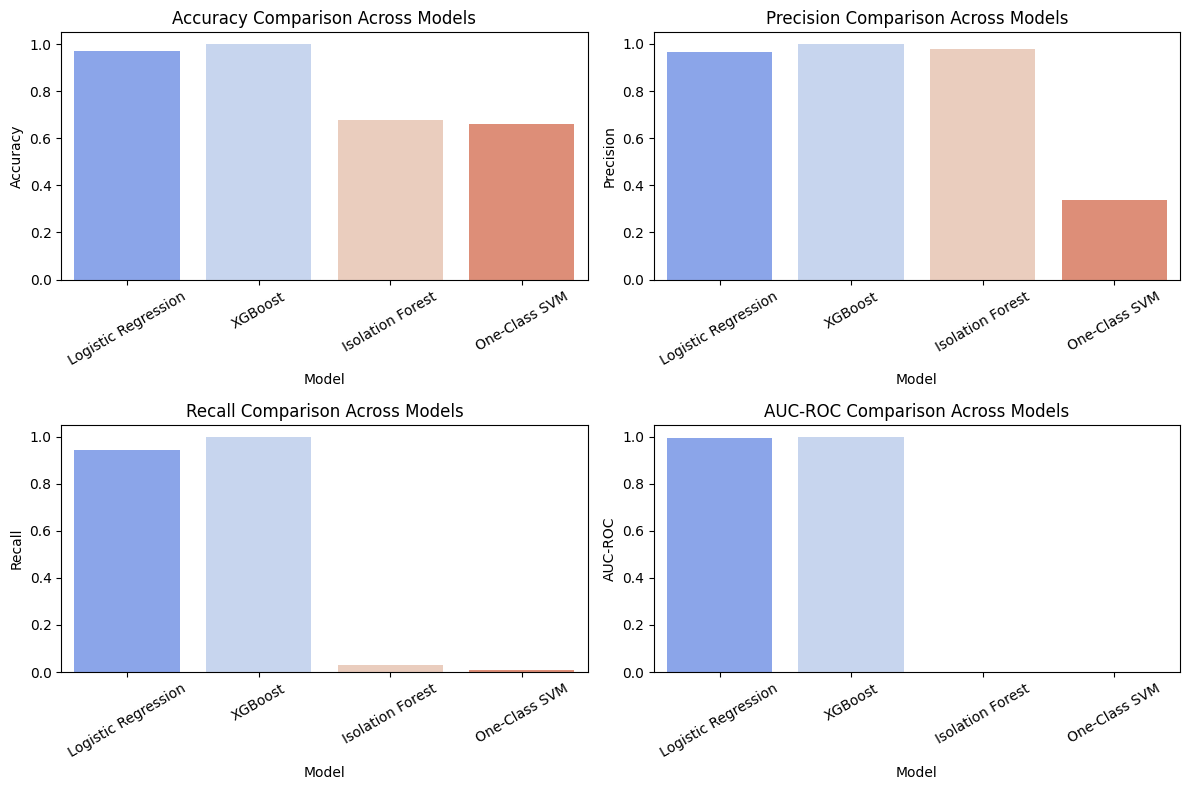

In [31]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, roc_curve
import seaborn as sns
# Dictionary to store model results
model_results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "AUC-ROC": []
}

# List of trained models
models = {
    "Logistic Regression": logistic_reg,
    "XGBoost": xgb,
    "Isolation Forest": isolation_forest,
    "One-Class SVM": oneclass_svm
}

# Evaluating each model
plt.figure(figsize=(8, 6)) 

for name, model in models.items():
    if name in ["Isolation Forest", "One-Class SVM"]:
        y_pred = model.predict(X_test)
        y_pred = [1 if x == -1 else 0 for x in y_pred]  
        y_probs = None 
    else:
        y_pred = model.predict(X_test)
        y_probs = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Compute performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_probs) if y_probs is not None else None

    # Store results
    model_results["Model"].append(name)
    model_results["Accuracy"].append(accuracy)
    model_results["Precision"].append(precision)
    model_results["Recall"].append(recall)
    model_results["AUC-ROC"].append(auc_roc if auc_roc is not None else 0)

    # Plot ROC curve if applicable as unsupervised models doesn't contain y_probs
    if y_probs is not None:
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_roc:.2f})")

# Finalized ROC curve plot
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Fraud Detection Models")
plt.legend()
plt.show()

# Converting the results to DataFrame for visualization
df_results = pd.DataFrame(model_results)

# Plotting the bar charts for Accuracy, Precision, Recall, and AUC-ROC
metrics = ["Accuracy", "Precision", "Recall", "AUC-ROC"]
plt.figure(figsize=(12, 8))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x=df_results["Model"], y=df_results[metric], palette="coolwarm")
    plt.title(f"{metric} Comparison Across Models")
    plt.ylabel(metric)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()




## Recall and Precision TradeOff

+ Precision: % of transactions flagged as fraud that are actually fraud.
+ Recall: % of actual fraud transactions correctly identified.


So we need to balance where the recall and precision are high.

# Why we are doing this?

+ For example, model like logistic regression will pedict as fraud if the output is greater than output, not fraud otherwise. 

+ If the threshold is 0.3 the model classifiy more non-frauds as frauds which is usually called as False Positives which leads to high precision. 

+ If the threshold is 0.7 the model might miss some frauds from being classifying them as frauds which leads to high recall.

+ This scenrio is called as Precision-Recall trade-off.

+ So,we find the optimum threshold that balances Precision and Recall after classification.



In [36]:
from sklearn.metrics import precision_recall_curve

y_probs = logistic_reg.predict_proba(X_test)[:, 1]  
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Find the best threshold where Precision = Recall
best_threshold = thresholds[np.argmax(precisions >= recalls)]
print("Optimal Fraud Threshold:", best_threshold)


# Applying the new threshold
y_pred_optimized = (y_probs >= best_threshold).astype(int)

# Evaluate new fraud detection performance
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_optimized))


Optimal Fraud Threshold: 0.4126211165194365
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     56777
           1       0.95      0.95      0.95     28518

    accuracy                           0.97     85295
   macro avg       0.96      0.96      0.96     85295
weighted avg       0.97      0.97      0.97     85295



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
